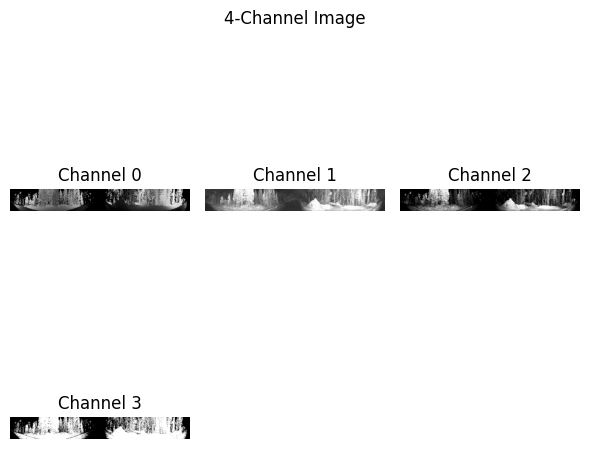

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def normalize_channel(channel):
    ch = channel.astype(np.float32)
    min_val = np.min(ch)
    max_val = np.max(ch)

    if max_val - min_val < 1e-6:
        return np.zeros_like(ch, dtype=np.uint8)

    ch = (ch - min_val) / (max_val - min_val)
    return (ch * 255).clip(0, 255).astype(np.uint8)

def visualize_image(path, save_path=None):
    img = Image.open(path)
    img_np = np.array(img)

    # Ensure (H, W, C)
    if img_np.ndim == 2:
        img_np = img_np[..., np.newaxis]

    H, W, C = img_np.shape

    # Normalize each channel independently
    norm_img = np.stack(
        [normalize_channel(img_np[..., c]) for c in range(C)],
        axis=-1
    )

    plt.figure(figsize=(6, 6))

    if C == 1:
        plt.imshow(norm_img[..., 0], cmap='gray')
        plt.title("Grayscale (Normalized)")
        plt.axis('off')

    elif C == 3:
        plt.imshow(norm_img)
        plt.title("RGB (Normalized)")
        plt.axis('off')

    else:
        # Show each channel separately (for 2, 4, etc.)
        cols = min(C, 3)
        rows = int(np.ceil(C / cols))

        for i in range(C):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(norm_img[..., i], cmap='gray')
            plt.title(f"Channel {i}")
            plt.axis('off')

        plt.suptitle(f"{C}-Channel Image")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

visualize_image("Data\\comb4-range-signal-reflec_and_range\\images\\train\\image_1.png", save_path="comb4_output.png")

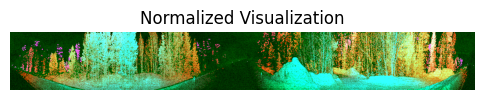

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def normalize_channel(channel):
    ch = channel.astype(np.float32)
    min_val = np.min(ch)
    max_val = np.max(ch)

    if max_val - min_val < 1e-6:
        return np.zeros_like(ch, dtype=np.uint8)

    ch = (ch - min_val) / (max_val - min_val)
    return (ch * 255).clip(0, 255).astype(np.uint8)

def to_rgb(norm_img):
    H, W, C = norm_img.shape

    if C == 1:
        # grayscale → RGB
        return np.repeat(norm_img, 3, axis=2)

    elif C == 2:
        # map to R, G, set B = 0
        B = np.zeros((H, W, 1), dtype=np.uint8)
        return np.concatenate([norm_img[..., 0:1], norm_img[..., 1:2], B], axis=2)

    elif C >= 3:
        # take first 3 channels
        return norm_img[..., :3]

def visualize_image(path, save_path=None):
    img = Image.open(path)
    img_np = np.array(img)

    if img_np.ndim == 2:
        img_np = img_np[..., np.newaxis]

    # Normalize each channel
    norm_img = np.stack(
        [normalize_channel(img_np[..., c]) for c in range(img_np.shape[2])],
        axis=-1
    )

    # Convert to RGB visualization
    rgb_img = to_rgb(norm_img)

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb_img)
    plt.title("Normalized Visualization")
    plt.axis('off')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


visualize_image("Data\\comb4-range-signal-reflec_and_range\\images\\train\\image_1.png", save_path="comb4_output.png")

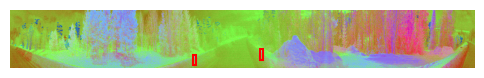

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

def normalize_channel(channel):
    ch = channel.astype(np.float32)
    min_val = np.min(ch)
    max_val = np.max(ch)

    if max_val - min_val < 1e-6:
        return np.zeros_like(ch, dtype=np.uint8)

    ch = (ch - min_val) / (max_val - min_val)
    return (ch * 255).clip(0, 255).astype(np.uint8)

def to_rgb(norm_img):
    H, W, C = norm_img.shape

    if C == 1:
        return np.repeat(norm_img, 3, axis=2)

    elif C == 2:
        B = np.zeros((H, W, 1), dtype=np.uint8)
        return np.concatenate([norm_img[..., 0:1], norm_img[..., 1:2], B], axis=2)

    else:
        return norm_img[..., :3]

def load_yolo_boxes(label_path, img_w, img_h):
    boxes = []

    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.strip().split())

            # Convert to pixel coords
            x_center = x * img_w
            y_center = y * img_h
            width = w * img_w
            height = h * img_h

            x_min = x_center - width / 2
            y_min = y_center - height / 2

            boxes.append((x_min, y_min, width, height, int(cls)))

    return boxes

def visualize_with_boxes(img_path, label_path, save_path=None):
    # --- Load image ---
    img = Image.open(img_path)
    img_np = np.array(img)

    if img_np.ndim == 2:
        img_np = img_np[..., np.newaxis]

    H, W, C = img_np.shape

    # --- Normalize ---
    norm_img = np.stack(
        [normalize_channel(img_np[..., c]) for c in range(C)],
        axis=-1
    )

    rgb_img = to_rgb(norm_img)

    # --- Load boxes ---
    boxes = load_yolo_boxes(label_path, W, H)

    # --- Plot ---
    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(rgb_img)

    for (x, y, w, h, cls) in boxes:
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=1.5,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    # ax.set_title("Snowpole Bounding Boxes")
    ax.axis('off')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


visualize_with_boxes(
    img_path="dataset_pca3\\images\\train\image_1.png",
    label_path="dataset_pca3/labels/train/image_1.txt",
    save_path="output_pca3with_boxes.png"
)